In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

# Loading the dataset

In [6]:
df = pd.read_csv("housing.csv")

# Inspecting data

In [10]:
df.shape

(20640, 10)

In [7]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [16]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Handling Missing Values

In [17]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

C:\Users\muabd\AppData\Local\Temp\ipykernel_13916\1590527289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [18]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Encoding the categorical column

In [19]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [20]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


# Visualizing the relationship between `median_income` and `median_house_value`

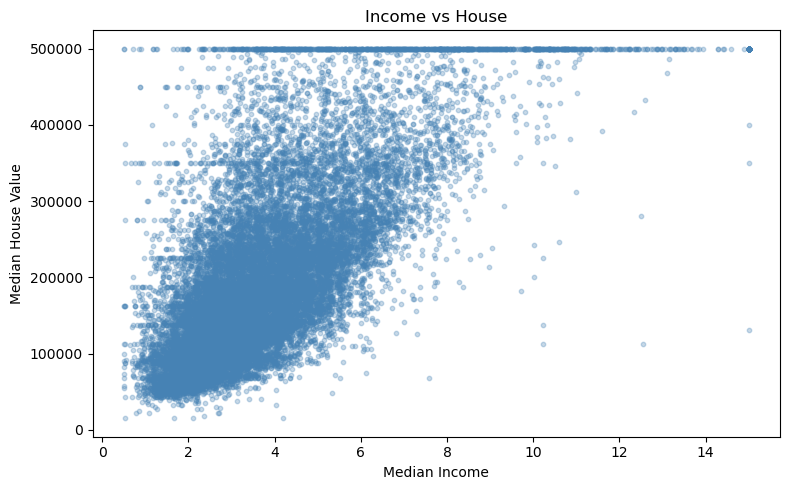

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3, s=10, color='steelblue')

plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.title("Income vs House")
plt.tight_layout()
plt.show()

# Splitting the data to train test split

In [23]:
X = df['median_income'].values
y = df['median_house_value'].values

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
print(X_train.shape)
print(X_test.shape)

(16512,)
(4128,)


# Linear Regression using OLS

In [28]:
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

In [29]:
num = np.sum((X_train - x_mean) * (y_train - y_mean))
denom = np.sum((X_train - x_mean) ** 2)

In [30]:
m = num / denom
b = y_mean - m * x_mean

In [35]:
print(f"Slope     (m): {m:.2f}")
print(f"Intercept (b): {b:.2f}")
print(f"House Value = {m:.2f} x median_income + {b:.2f}")

Slope     (m): 41933.85
Intercept (b): 44459.73
House Value = 41933.85 x median_income + 44459.73


In [36]:
y_pred = m * X_test + b

In [37]:
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

In [39]:
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MSE:  7,091,157,771.77
RMSE: 84,209.01


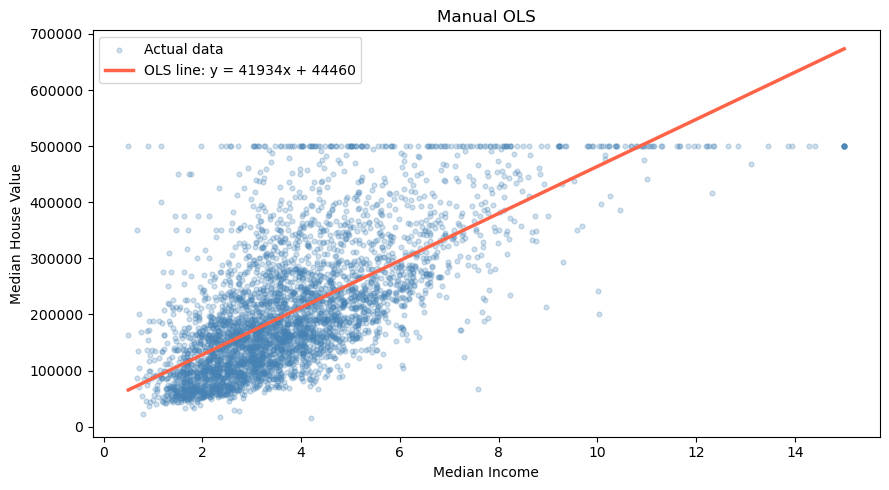

In [48]:
plt.figure(figsize=(9,5))
plt.scatter(X_test, y_test,
            alpha=0.25, s=12, color='steelblue', label='Actual data')

x_line = np.linspace(X_test.min(), X_test.max(), 200)
plt.plot(x_line, m * x_line + b,
         color='tomato', linewidth=2.5,
         label=f'OLS line: y = {m:.0f}x + {b:.0f}')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Manual OLS')
plt.legend()
plt.tight_layout()
plt.show()

# Linear Regression using scikit-learn

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

# Comparison of manual and scikit-learn

In [46]:
print("── Verification ───────────────────────")
print(f"Manual m:   {m:.6f}")
print(f"Sklearn m:  {model.coef_[0]:.6f}")

print(f"\nManual b:   {b:.6f}")
print(f"Sklearn b:  {model.intercept_:.6f}")

── Verification ───────────────────────
Manual m:   41933.849394
Sklearn m:  41933.849394

Manual b:   44459.729169
Sklearn b:  44459.729169


# Multiple Linear Regression

In [53]:
X = df.drop(columns=['median_house_value']).values
y = df['median_house_value'].values

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling

In [58]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

X_mean = X_train.mean(axis=0)   
X_std  = X_train.std(axis=0)     

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std

In [60]:
n_train = X_train_scaled.shape[0]
n_test  = X_test_scaled.shape[0]

X_train_b = np.column_stack([np.ones(n_train), X_train_scaled])
X_test_b  = np.column_stack([np.ones(n_test),  X_test_scaled])

In [ ]:
X = X_train_b
y = y_train


# w = (XᵀX)⁻¹ Xᵀy
XtX     = X.T @ X 
XtX_inv = np.linalg.inv(XtX)
Xty     = X.T @ y
w       = XtX_inv @ Xty

In [65]:
y_pred = X_test_b @ w

mse  = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE:  4908476721.16
RMSE: 70060.52


In [66]:
print("Manual Linear Regression RMSE: 84,209")
print("Manual Multiple Linear Regression RMSE: 70,060")

Manual Linear Regression RMSE: 84,209
Manual Multiple Linear Regression RMSE: 70,060
